In [1]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

In [2]:
# Load team ratings dataset
df = pd.read_csv('../data/clean/baseball_games_elo.csv')

In [3]:
df.duplicated().sum()


0

# View data details

In [4]:
df.head()

,date,away,home,away_score,home_score,winning_team,elo1_pre,elo2_pre,elo_prob1,elo_prob2,elo1_post,elo2_post
0,2007-02-16,taylor (in),tennessee temple,5,4,taylor (in),1500.000000,1500.000000,0.500000,0.500000,1487.198700,1512.801300
1,2007-02-16,taylor (in),tennessee temple,4,0,taylor (in),1487.198700,1512.801300,0.463221,0.536779,1475.089510,1524.910490
2,2007-02-17,taylor (in),tennessee temple,9,3,taylor (in),1475.089510,1524.910490,0.428789,0.571211,1463.655201,1536.344799
3,2007-02-17,taylor (in),tennessee temple,5,6,tennessee temple,1463.655201,1536.344799,0.396891,0.603109,1452.870759,1547.129241
4,2007-02-22,huntington (in),freed-hardeman,12,6,huntington (in),1500.000000,1500.000000,0.500000,0.500000,1507.198700,1492.801300


In [5]:
df.describe()

,away_score,home_score,elo1_pre,elo2_pre,elo_prob1,elo_prob2,elo1_post,elo2_post
count,5010.000000,5010.000000,5010.000000,5010.000000,5010.000000,5010.000000,5010.000000,5010.000000
mean,5.578443,6.205190,1503.995635,1523.943926,0.486734,0.513266,1502.432953,1525.506608
std,4.520349,4.637273,274.900996,267.290160,0.323939,0.323939,275.512579,268.167750
min,0.000000,0.000000,714.533301,715.606040,0.000146,0.000221,714.462489,714.533301
25%,2.000000,3.000000,1345.359851,1384.315106,0.186062,0.212036,1343.250608,1384.879708
50%,5.000000,5.000000,1494.721867,1500.000000,0.471266,0.528734,1489.333389,1499.614292
75%,8.000000,9.000000,1654.458538,1646.250636,0.787964,0.813938,1654.072419,1652.417224
max,43.000000,42.000000,2270.228402,2270.258955,0.999779,0.999854,2270.258955,2270.197838


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5010 entries, 0 to 5009
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          5010 non-null   str    
 1   away          5010 non-null   str    
 2   home          5010 non-null   str    
 3   away_score    5010 non-null   int64  
 4   home_score    5010 non-null   int64  
 5   winning_team  5010 non-null   str    
 6   elo1_pre      5010 non-null   float64
 7   elo2_pre      5010 non-null   float64
 8   elo_prob1     5010 non-null   float64
 9   elo_prob2     5010 non-null   float64
 10  elo1_post     5010 non-null   float64
 11  elo2_post     5010 non-null   float64
dtypes: float64(6), int64(2), str(4)
memory usage: 744.1 KB


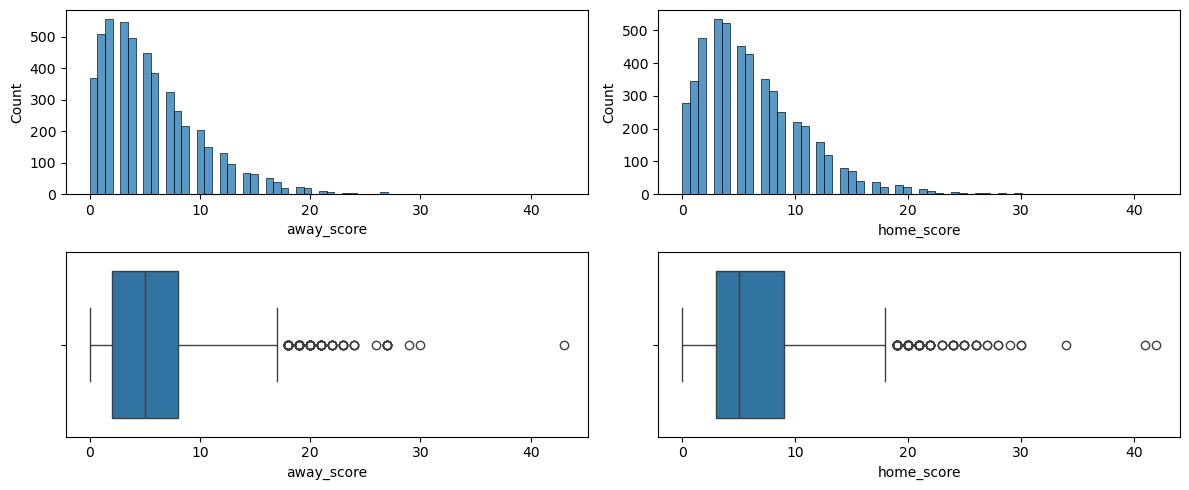

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 5))
sns.histplot(data=df, x=df['away_score'], ax=axes[0][0])
sns.histplot(data=df, x=df['home_score'], ax=axes[0][1])
sns.boxplot(data=df, x=df['away_score'], ax=axes[1][0])
sns.boxplot(data=df, x=df['home_score'], ax=axes[1][1])

plt.tight_layout()
plt.show()

# Preprocess Data

In [8]:
df_clean = df.copy()

In [9]:
# Label encode the categorical features (away, home, winning_team)
